In [2]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, label_binarize
from category_encoders import BinaryEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [3]:
df_applications = pd.read_csv('./data/cleaned_data/applications.csv')

In [4]:
df_transactions = pd.read_csv('./data/cleaned_data/transactions.csv')

In [5]:
df_completion = pd.read_csv('./data/cleaned_data/completions.csv')

In [6]:
from category_encoders import BinaryEncoder

def preprocess_for_pca_binary_encoding(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocesses the DataFrame for PCA by:
    1. Encoding non-numeric features using binary encoding
    2. Combining with numeric features
    3. Handling missing values by dropping rows with any NaNs
    4. Standardizing the data

    Parameters:
    df (pd.DataFrame): Raw input DataFrame

    Returns:
    pd.DataFrame: Standardized DataFrame ready for PCA
    """
    numeric_df = df.select_dtypes(include='number')
    categorical_df = df.select_dtypes(exclude='number')

    if not categorical_df.empty:
        encoder = BinaryEncoder()
        encoded_df = encoder.fit_transform(categorical_df)
        full_df = pd.concat([numeric_df, encoded_df], axis=1)
    else:
        full_df = numeric_df

    clean_df = full_df.dropna()

    scaler = StandardScaler()
    standardized_data = scaler.fit_transform(clean_df)

    return pd.DataFrame(standardized_data, columns=clean_df.columns, index=clean_df.index)

In [7]:
def plot_pca_feature_importance(df: pd.DataFrame, original_df: pd.DataFrame, n_components: int = 5, top_n: int = 20):
    """
    Visualizes the most important features using PCA loadings and decodes binary-encoded feature names to their original values.

    Parameters:
    df (pd.DataFrame): DataFrame ready for PCA (will filter to numeric only)
    original_df (pd.DataFrame): Original dataframe before encoding
    n_components (int): Number of principal components to consider
    top_n (int): Number of top features to display
    """
    # Ensure numeric columns only for PCA
    df_numeric = df.select_dtypes(include=[np.number])
    if df.shape[1] != df_numeric.shape[1]:
        dropped = set(df.columns) - set(df_numeric.columns)
        print(f"Warning: Dropped non-numeric columns: {dropped}")

    # Detect categorical columns automatically
    categorical_cols = original_df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Build mappings from encoded column to original label values
    encoded_label_map = {}
    for col in categorical_cols:
        encoder = BinaryEncoder(cols=[col])
        encoder.fit(original_df[[col]])
        unique_values = original_df[col].dropna().unique().tolist()
        for i, encoded in enumerate(encoder.get_feature_names_out([col])):
            category_hint = unique_values[i] if i < len(unique_values) else ""
            encoded_label_map[encoded] = f"{encoded} ({category_hint})"

    # Fit PCA and compute importance
    pca = PCA(n_components=n_components).fit(df_numeric)
    importance = np.sum(pca.components_.T ** 2, axis=1)
    top_features = pd.Series(importance, index=df_numeric.columns).nlargest(top_n)

    # Decode feature labels
    decoded_labels = [encoded_label_map.get(col, col) for col in top_features.index]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(decoded_labels, top_features.values)
    plt.title(f"Top {top_n} Most Important Features by PCA")
    plt.ylabel("Sum of Squared Loadings")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [8]:
def get_top_features_by_pca(df: pd.DataFrame, top_k: int = 10, n_components: int = 15) -> list:
    """
    Dynamically selects top-k important features (categorical and numeric) using PCA loadings,
    and visualizes their contributions.

    Parameters:
    df (pd.DataFrame): Input DataFrame with mixed types
    top_k (int): Number of top features to keep
    n_components (int): Number of PCA components to consider

    Returns:
    List[str]: Selected original features based on PCA loadings
    """
    # Drop rows with any missing values
    df = df.dropna()

    # Separate categorical and numeric features
    categorical_df = df.select_dtypes(exclude='number')
    numeric_df = df.select_dtypes(include='number')

    # Binary encode categorical
    encoder = BinaryEncoder()
    encoded_df = encoder.fit_transform(categorical_df)
    feature_names = encoder.get_feature_names_out()
    encoded_df.columns = feature_names

    # Map binary columns to original categorical features
    col_to_feature = {col: col.rsplit('_', 1)[0] for col in encoded_df.columns}

    # Combine numeric and encoded categorical features
    full_df = pd.concat([numeric_df, encoded_df], axis=1)

    # Add numeric feature names to mapping directly
    for col in numeric_df.columns:
        col_to_feature[col] = col

    # Standardize all features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(full_df)

    # PCA
    pca = PCA(n_components=n_components)
    pca.fit(X_scaled)
    loadings = pca.components_.T

    # Compute sum of squared loadings by original feature
    loading_df = pd.DataFrame(loadings, index=full_df.columns)
    loading_df['sum_squared'] = loading_df.iloc[:, :n_components].pow(2).sum(axis=1)

    feature_scores = loading_df.groupby(col_to_feature).sum()['sum_squared'].sort_values(ascending=False)
    top_features = feature_scores.head(top_k).index.tolist()

    # Plot top features
    plt.figure(figsize=(10, 6))
    feature_scores.head(top_k).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_k} Important Features by PCA (Categorical + Numeric)")
    plt.xlabel("Aggregated Sum of Squared PCA Loadings")
    plt.tight_layout()
    plt.show()

    # Print summary
    print("\nFeature Importance Summary:")
    for feature in top_features:
        score = feature_scores[feature]
        print(f"- {feature}: contributes strongly across the first {n_components} PCA components (score: {score:.4f})")

    return top_features


In [9]:
df_applications_pca_binary= preprocess_for_pca_binary_encoding(df_applications)

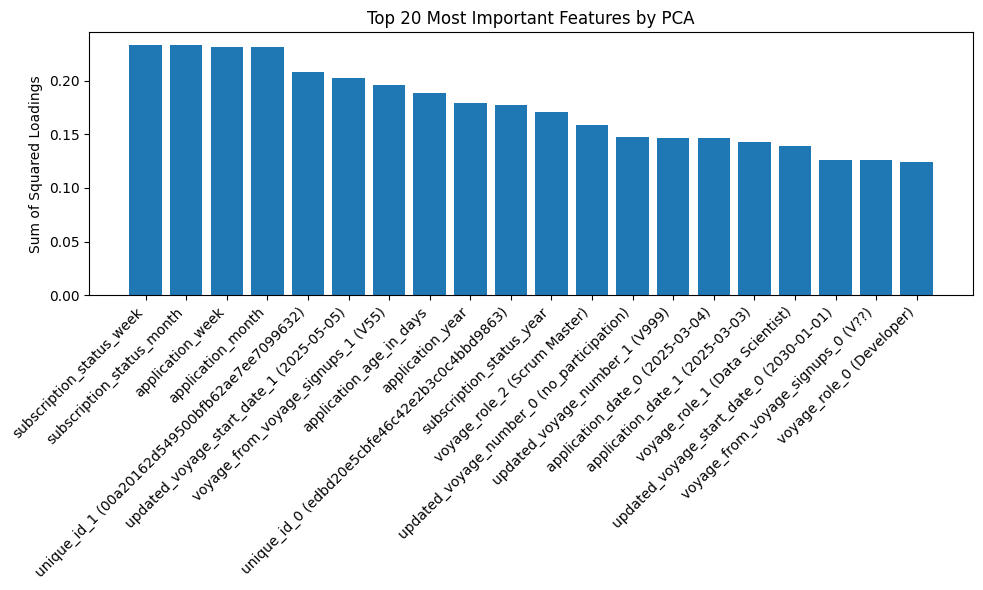

In [10]:
plot_pca_feature_importance(df_applications_pca_binary, df_applications)

In [11]:
df_transactions_pca_binary = preprocess_for_pca_binary_encoding(df_transactions)

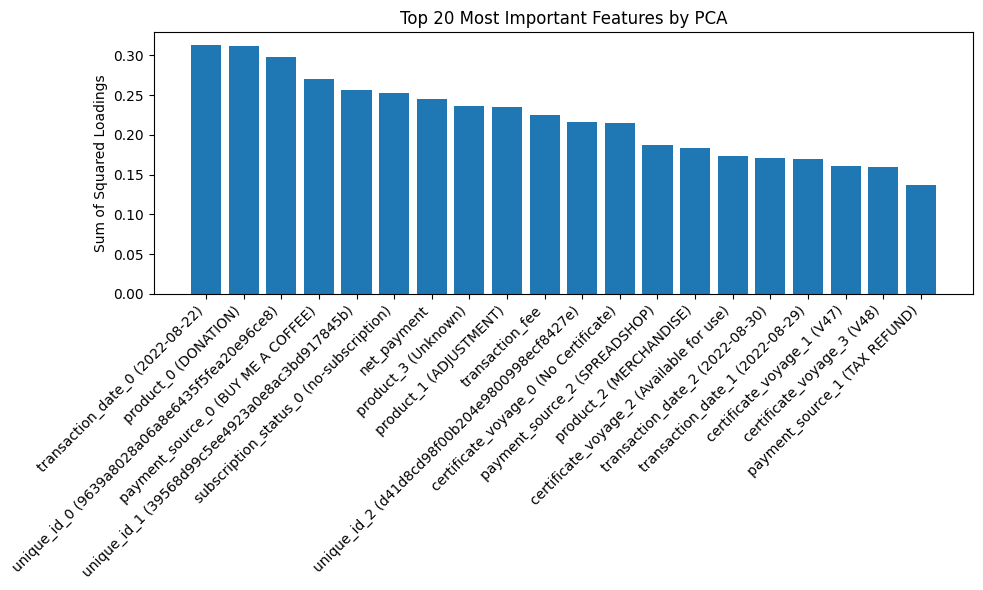

In [12]:
plot_pca_feature_importance(df_transactions_pca_binary , df_transactions)

In [13]:
df_completion_pca_binary = preprocess_for_pca_binary_encoding(df_completion)

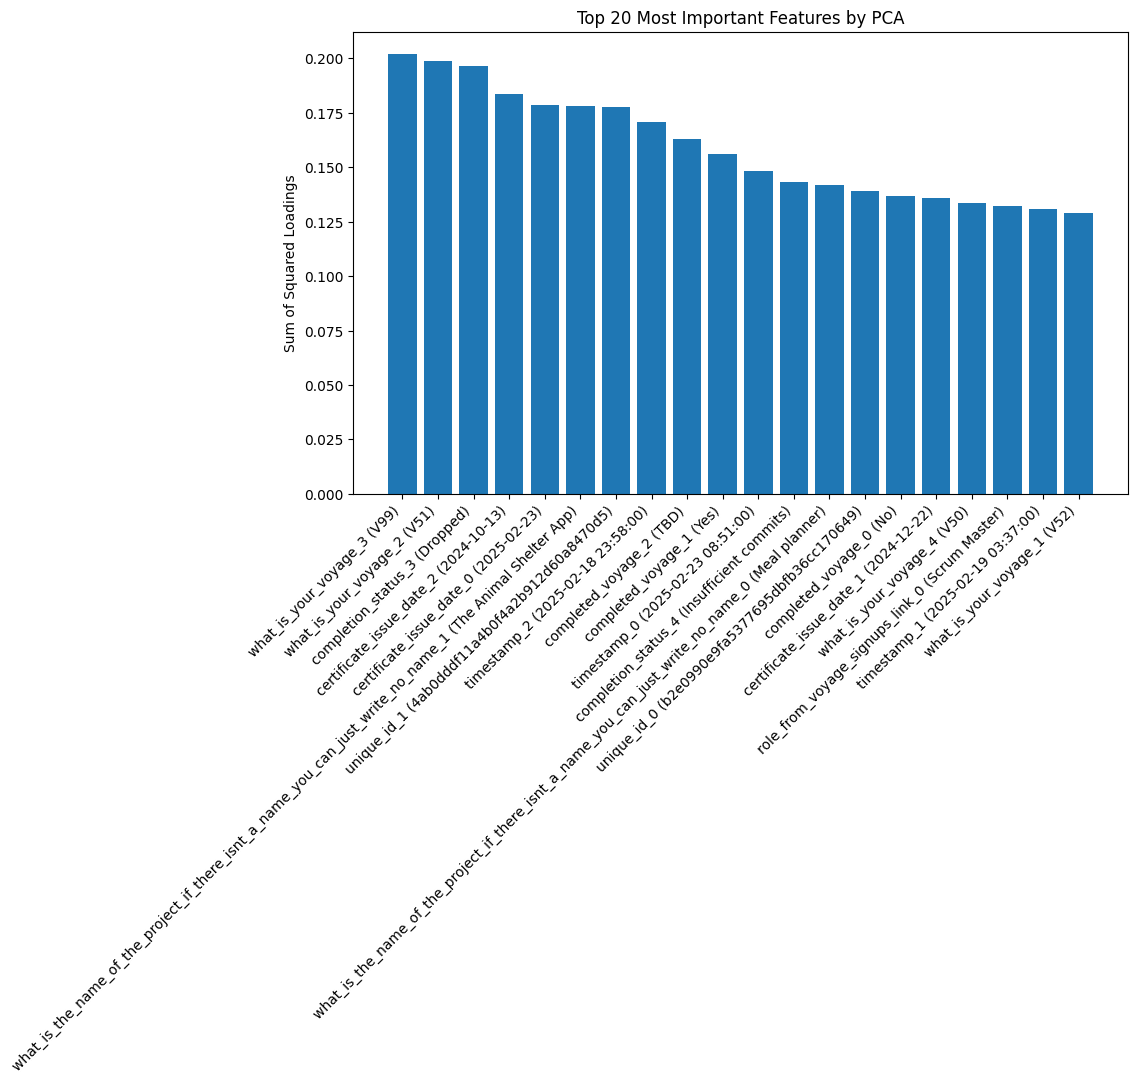

In [14]:
plot_pca_feature_importance(df_completion_pca_binary , df_completion)

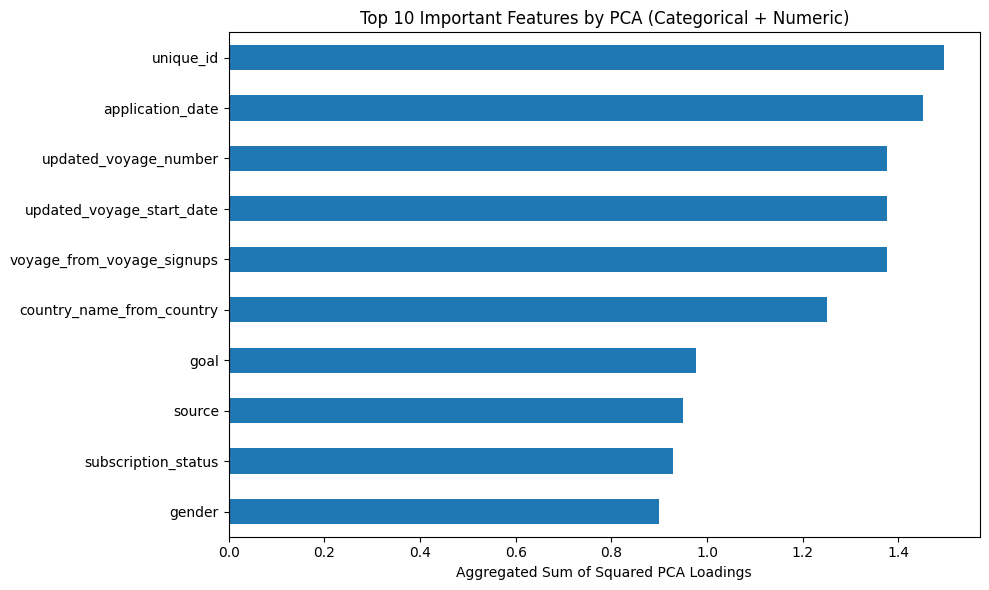


Feature Importance Summary:
- unique_id: contributes strongly across the first 15 PCA components (score: 1.4956)
- application_date: contributes strongly across the first 15 PCA components (score: 1.4523)
- updated_voyage_number: contributes strongly across the first 15 PCA components (score: 1.3762)
- updated_voyage_start_date: contributes strongly across the first 15 PCA components (score: 1.3762)
- voyage_from_voyage_signups: contributes strongly across the first 15 PCA components (score: 1.3762)
- country_name_from_country: contributes strongly across the first 15 PCA components (score: 1.2505)
- goal: contributes strongly across the first 15 PCA components (score: 0.9764)
- source: contributes strongly across the first 15 PCA components (score: 0.9490)
- subscription_status: contributes strongly across the first 15 PCA components (score: 0.9287)
- gender: contributes strongly across the first 15 PCA components (score: 0.8986)


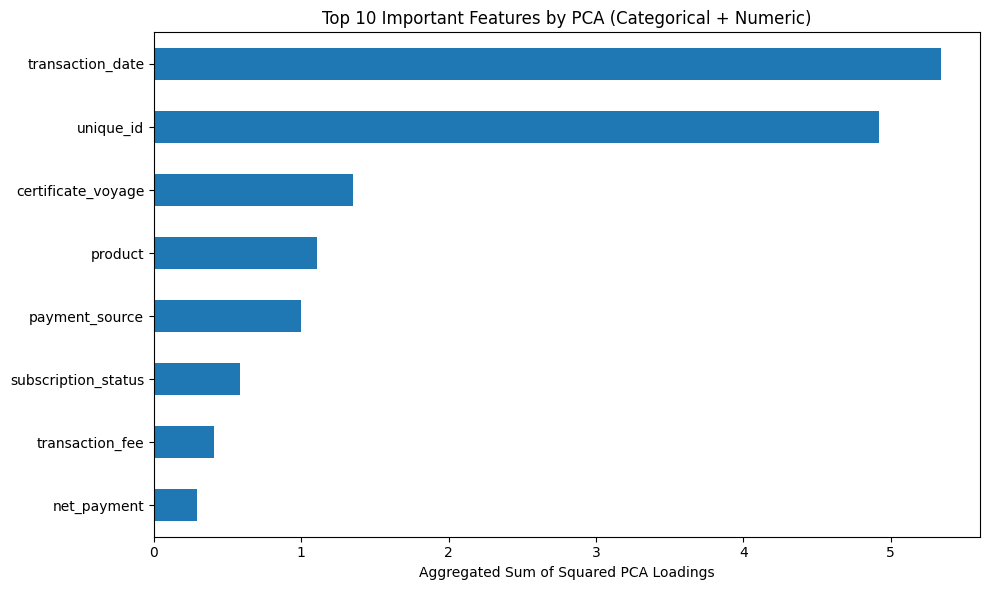


Feature Importance Summary:
- transaction_date: contributes strongly across the first 15 PCA components (score: 5.3393)
- unique_id: contributes strongly across the first 15 PCA components (score: 4.9237)
- certificate_voyage: contributes strongly across the first 15 PCA components (score: 1.3503)
- product: contributes strongly across the first 15 PCA components (score: 1.1071)
- payment_source: contributes strongly across the first 15 PCA components (score: 0.9950)
- subscription_status: contributes strongly across the first 15 PCA components (score: 0.5849)
- transaction_fee: contributes strongly across the first 15 PCA components (score: 0.4048)
- net_payment: contributes strongly across the first 15 PCA components (score: 0.2949)


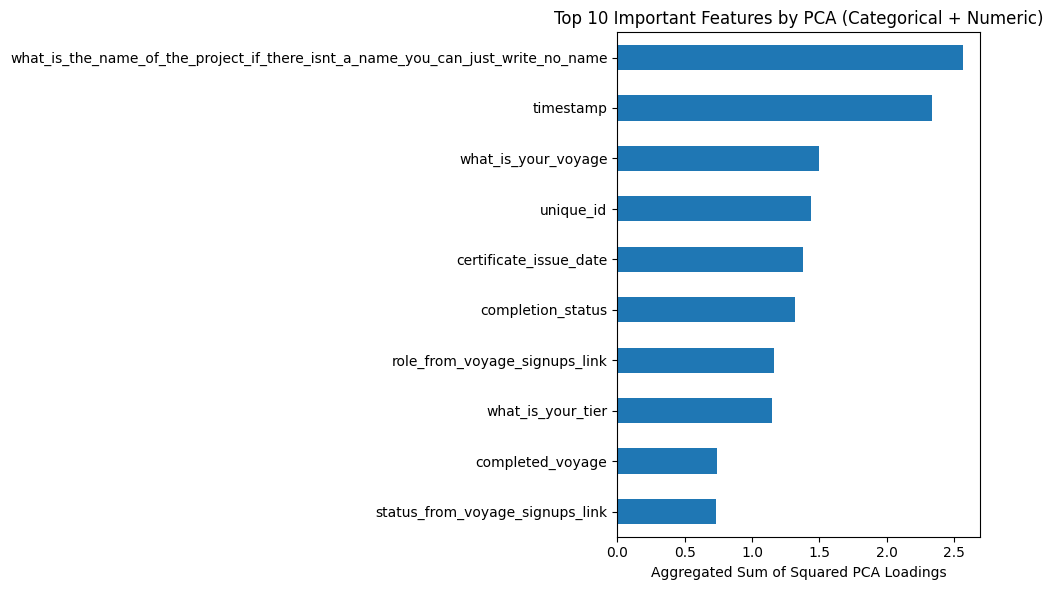


Feature Importance Summary:
- what_is_the_name_of_the_project_if_there_isnt_a_name_you_can_just_write_no_name: contributes strongly across the first 15 PCA components (score: 2.5637)
- timestamp: contributes strongly across the first 15 PCA components (score: 2.3329)
- what_is_your_voyage: contributes strongly across the first 15 PCA components (score: 1.4942)
- unique_id: contributes strongly across the first 15 PCA components (score: 1.4413)
- certificate_issue_date: contributes strongly across the first 15 PCA components (score: 1.3781)
- completion_status: contributes strongly across the first 15 PCA components (score: 1.3226)
- role_from_voyage_signups_link: contributes strongly across the first 15 PCA components (score: 1.1622)
- what_is_your_tier: contributes strongly across the first 15 PCA components (score: 1.1514)
- completed_voyage: contributes strongly across the first 15 PCA components (score: 0.7375)
- status_from_voyage_signups_link: contributes strongly across the fir

In [15]:
applications_important_fields = get_top_features_by_pca(df_applications)
transactions_important_fields = get_top_features_by_pca(df_transactions)
completion_important_fileds = get_top_features_by_pca(df_completion)

In [16]:
print(applications_important_fields, transactions_important_fields, completion_important_fileds)

['unique_id', 'application_date', 'updated_voyage_number', 'updated_voyage_start_date', 'voyage_from_voyage_signups', 'country_name_from_country', 'goal', 'source', 'subscription_status', 'gender'] ['transaction_date', 'unique_id', 'certificate_voyage', 'product', 'payment_source', 'subscription_status', 'transaction_fee', 'net_payment'] ['what_is_the_name_of_the_project_if_there_isnt_a_name_you_can_just_write_no_name', 'timestamp', 'what_is_your_voyage', 'unique_id', 'certificate_issue_date', 'completion_status', 'role_from_voyage_signups_link', 'what_is_your_tier', 'completed_voyage', 'status_from_voyage_signups_link']


In [17]:
df_applications_selected = df_applications[applications_important_fields]
df_transactions_selected = df_transactions[transactions_important_fields]
df_completion_selected = df_completion[completion_important_fileds]

In [18]:
df_merged = df_applications_selected.merge(
    df_transactions_selected,
    on='unique_id',
    how='inner',
    suffixes=('_Applications', '_Transactions')
)

In [19]:
df_merged.head()

,unique_id,application_date,updated_voyage_number,updated_voyage_start_date,voyage_from_voyage_signups,country_name_from_country,goal,source,subscription_status_Applications,gender,transaction_date,certificate_voyage,product,payment_source,subscription_status_Transactions,transaction_fee,net_payment
0,dadffe486c63fc05d8b3afee2c4dc132,2025-02-18,no_participation,NaN,NaN,Canada,GAIN EXPERIENCE,The Job Hackers,Active,FEMALE,2025-01-04,No Certificate,SUBSCRIPTION - Junior Professional,STRIPE,active,0.43,2.56
1,dadffe486c63fc05d8b3afee2c4dc132,2025-02-18,no_participation,NaN,NaN,Canada,GAIN EXPERIENCE,The Job Hackers,Active,FEMALE,2025-02-01,No Certificate,SUBSCRIPTION - Junior Professional,DISCORD,active,0.30,2.69
2,56a8ef8425ff0595bd660065cae07793,2025-01-03,V53,2025-01-06,V53,United Kingdom,GAIN EXPERIENCE,PERSONAL NETWORK,Active,FEMALE,2025-02-20,No Certificate,SUBSCRIPTION - Junior Professional,DISCORD,active,0.30,2.69
3,56a8ef8425ff0595bd660065cae07793,2025-01-03,V54,2025-03-03,V54,United Kingdom,GAIN EXPERIENCE,PERSONAL NETWORK,Active,FEMALE,2025-02-20,No Certificate,SUBSCRIPTION - Junior Professional,DISCORD,active,0.30,2.69
4,0a534d132b4dcf8e3b3dad5d766cac4b,2025-01-03,V53,2025-01-06,V53,United States,ACCELERATE LEARNING,LinkedIn,Active,FEMALE,2025-01-16,No Certificate,SUBSCRIPTION - Professional,DISCORD,ended,1.00,8.99


In [20]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2287 entries, 0 to 2286
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   unique_id                         2287 non-null   object 
 1   application_date                  2286 non-null   object 
 2   updated_voyage_number             2287 non-null   object 
 3   updated_voyage_start_date         2227 non-null   object 
 4   voyage_from_voyage_signups        2227 non-null   object 
 5   country_name_from_country         2287 non-null   object 
 6   goal                              2287 non-null   object 
 7   source                            2287 non-null   object 
 8   subscription_status_Applications  2287 non-null   object 
 9   gender                            2287 non-null   object 
 10  transaction_date                  2287 non-null   object 
 11  certificate_voyage                2287 non-null   object 
 12  produc

In [22]:
import os 
import sys
sys.path.append(os.path.abspath('./modules'))

In [23]:
from EDA import EDA

In [24]:
df_merged.to_csv('./data/merged_applications_transactions.csv')

In [27]:
X = df_merged.drop(columns=['subscription_status_Transactions' , 'unique_id'])
y = df_merged['subscription_status_Transactions']

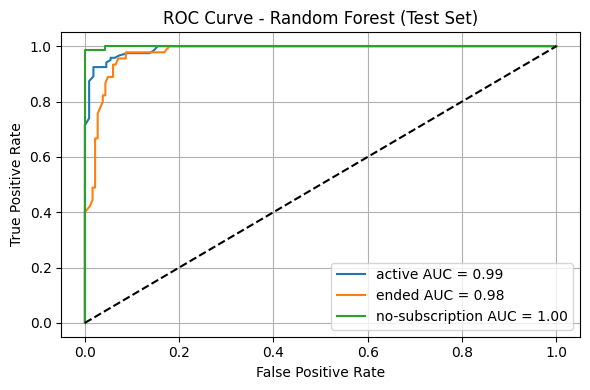

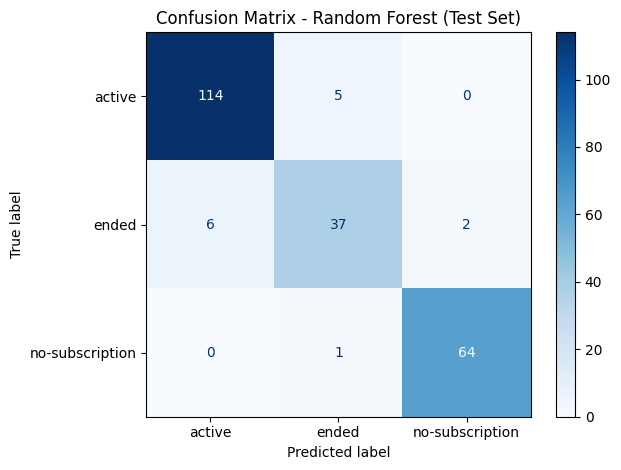

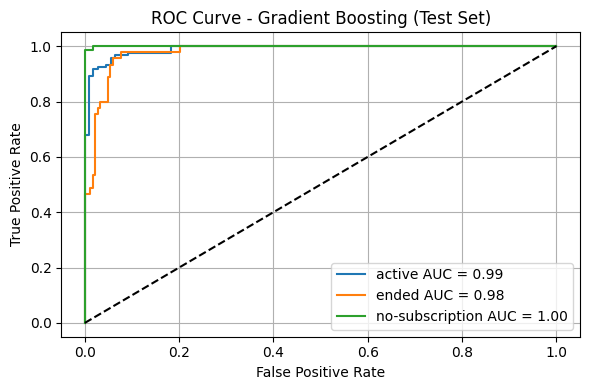

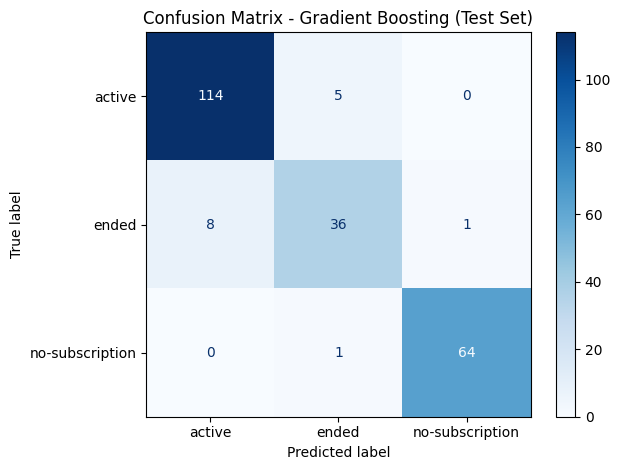

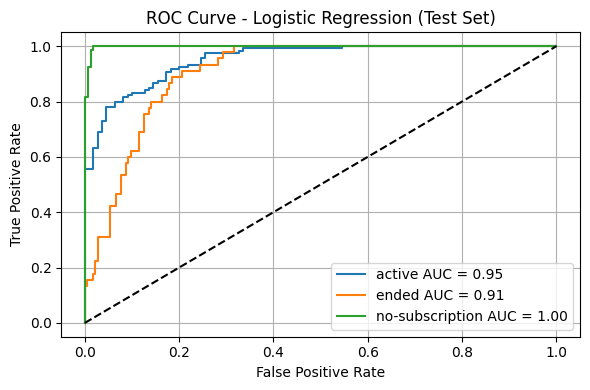

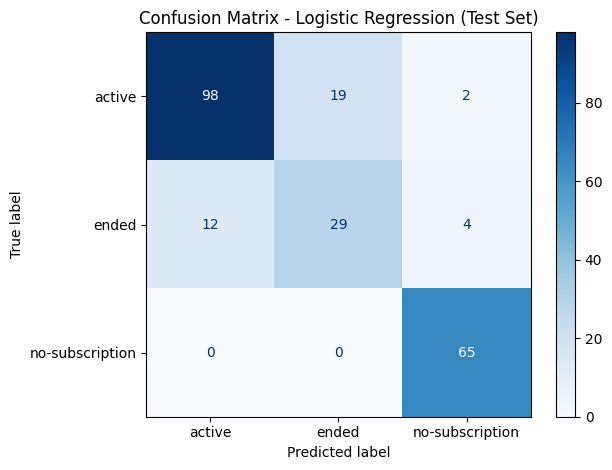

Random Forest: Accuracy=0.9448, F1=0.9431, ROC AUC=0.9930


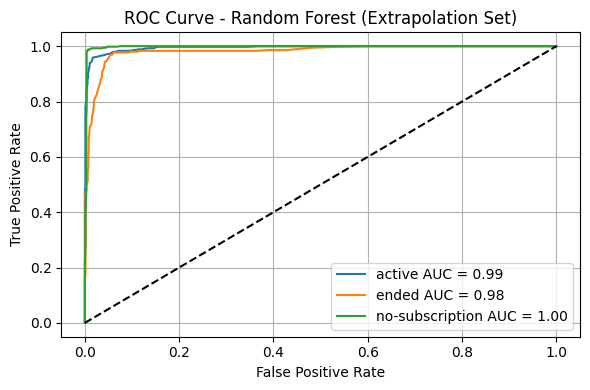

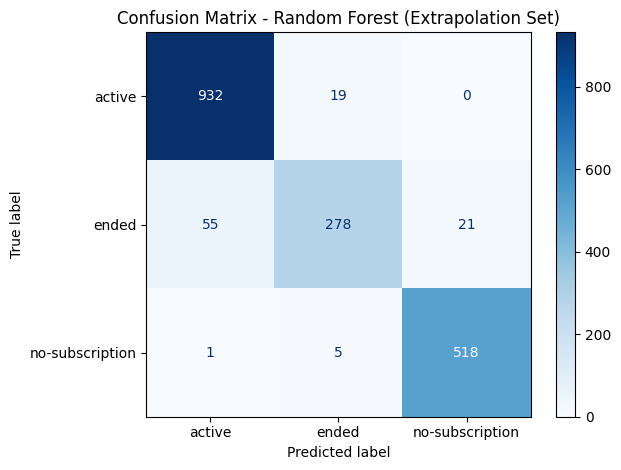

Gradient Boosting: Accuracy=0.9557, F1=0.9551, ROC AUC=0.9920


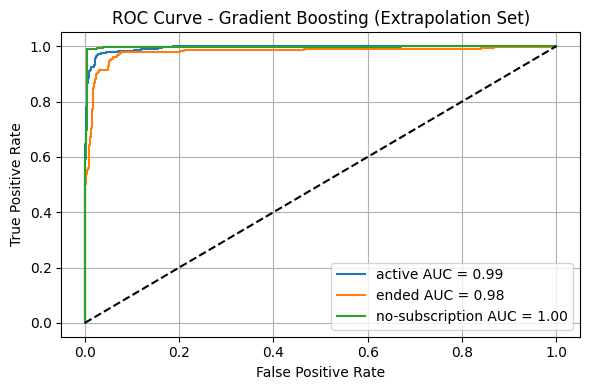

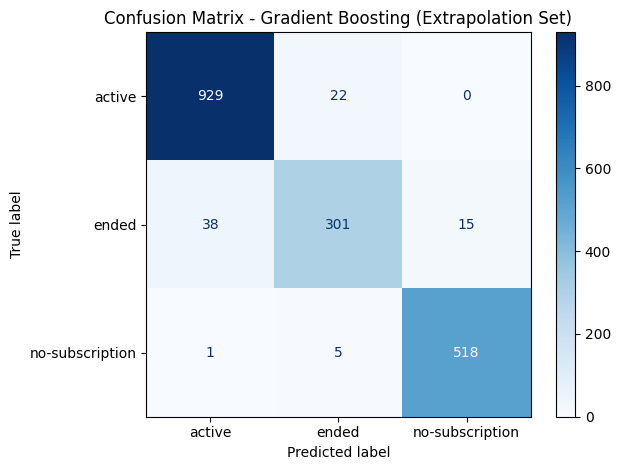

Logistic Regression: Accuracy=0.8644, F1=0.8640, ROC AUC=0.9559


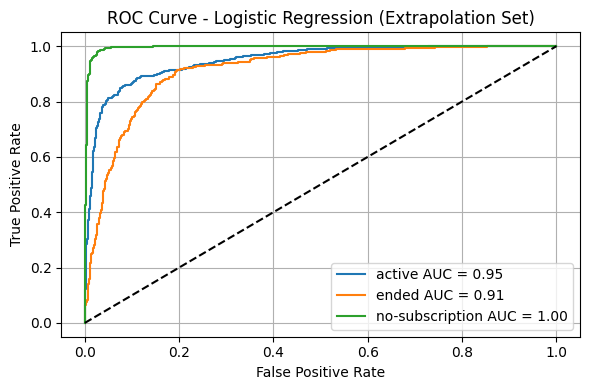

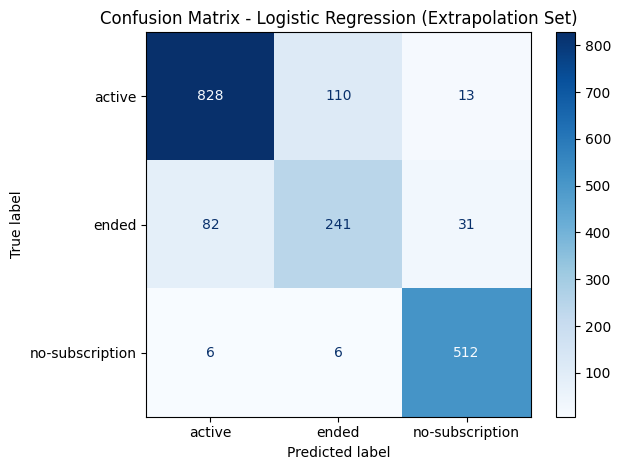

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ROC curves and confusion matrix on test set
for name, model in models.items():
    y_score = model.fit(X_train, y_train_encoded).predict_proba(X_test)
    y_pred_test = model.predict(X_test)

    # ROC Curve
    plt.figure(figsize=(6, 4))
    for i in range(y_test_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        label = label_encoder.classes_[i]
        plt.plot(fpr, tpr, label=f'{label} AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - {name} (Test Set)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Confusion Matrix
    cm_test = confusion_matrix(y_test_encoded, y_pred_test)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=label_encoder.classes_)
    disp_test.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (Test Set)')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# Evaluation + ROC + Confusion Matrix on extrapolation
for name, model in models.items():
    y_pred = model.predict(X_extra)
    acc = accuracy_score(y_extra_encoded, y_pred)
    f1 = f1_score(y_extra_encoded, y_pred, average='weighted')
    y_prob = model.predict_proba(X_extra)
    y_bin = label_binarize(y_extra_encoded, classes=np.unique(y_train_encoded))
    auc = roc_auc_score(y_bin, y_prob, average='weighted', multi_class='ovr')
    print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}, ROC AUC={auc:.4f}")

    # ROC Curve
    plt.figure(figsize=(6, 4))
    for i in range(y_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_class = roc_auc_score(y_bin[:, i], y_prob[:, i])
        label = label_encoder.classes_[i]
        plt.plot(fpr, tpr, label=f'{label} AUC = {auc_class:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - {name} (Extrapolation Set)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Confusion Matrix
    cm_extra = confusion_matrix(y_extra_encoded, y_pred)
    disp_extra = ConfusionMatrixDisplay(confusion_matrix=cm_extra, display_labels=label_encoder.classes_)
    disp_extra.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (Extrapolation Set)')
    plt.grid(False)
    plt.tight_layout()
    plt.show()


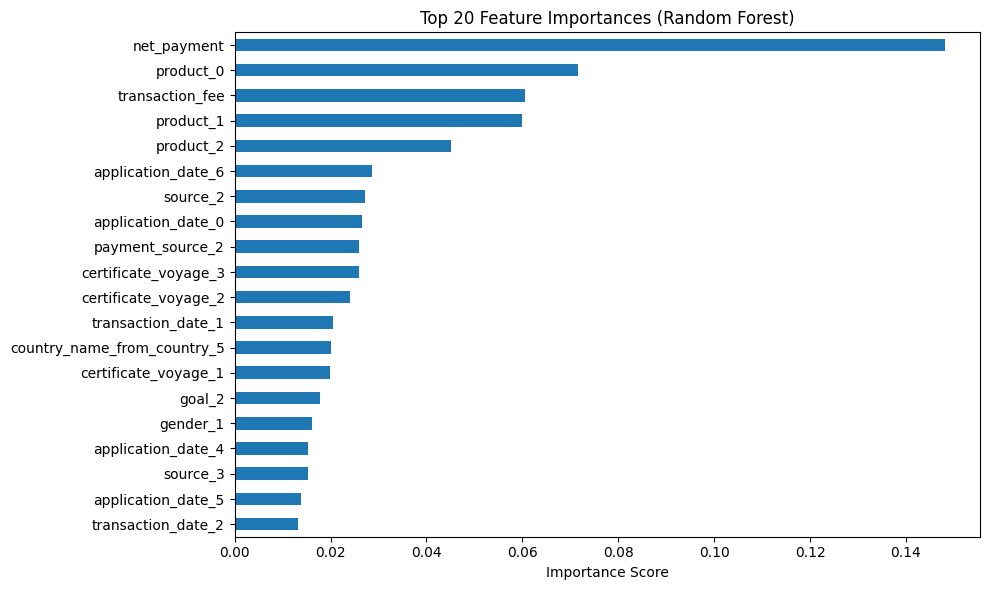

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importances from the trained model
importances = best_rf_model.feature_importances_
features = X_train.columns
importance_df = pd.Series(importances, index=features).sort_values(ascending=False)

# Plot
importance_df.head(20).plot(kind='barh', figsize=(10, 6))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import  KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

def train_regression_with_cv(X: pd.DataFrame, y: pd.Series):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    models_params = {
        'Random Forest': (RandomForestRegressor(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }),
        'Gradient Boosting': (GradientBoostingRegressor(random_state=42), {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }),
        'Polynomial Ridge': (make_pipeline(PolynomialFeatures(degree=2), Ridge()), {
            'ridge__alpha': np.arange(0.1, 7.1, 0.2).tolist()
        })
    }

    best_model, best_score, best_name = None, -np.inf, ""

    for name, (model, params) in models_params.items():
        grid = GridSearchCV(model, params, cv=cv, scoring='r2')
        grid.fit(X, y)
        score = grid.best_score_
        print(f"{name} Best R2: {score:.4f}")
        if score > best_score:
            best_model, best_score, best_name = grid.best_estimator_, score, name

    print(f"Selected Model: {best_name}")
    return best_model



X = df_merged.drop(columns=['unique_id', 'net_payment'])
y = df_merged['net_payment']
encoder = BinaryEncoder()
X_encoded = encoder.fit_transform(X)
X_extra, X_intra, y_extra, y_intra = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_intra, y_intra, test_size=0.5, random_state=42)

best_model = train_regression_with_cv(X_train, y_train)
y_pred = best_model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Random Forest Best R2: 0.6207
Gradient Boosting Best R2: 0.7331
Polynomial Ridge Best R2: 0.6050
Selected Model: Gradient Boosting
MAE: 0.4446584342969054
R2: 0.8275672255182871


MAE: 0.4446584342969054
R2: 0.8275672255182871


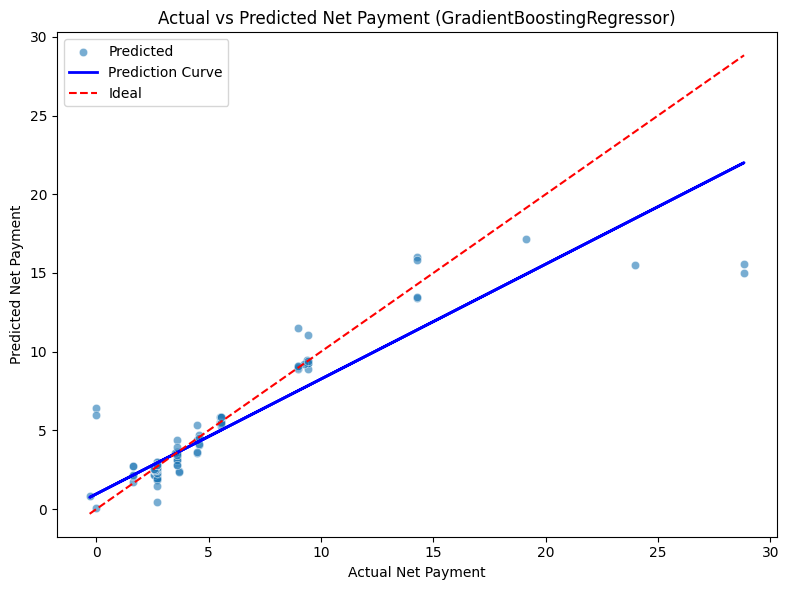

MAE: 0.49241471627221484
R2: 0.7511302294230983


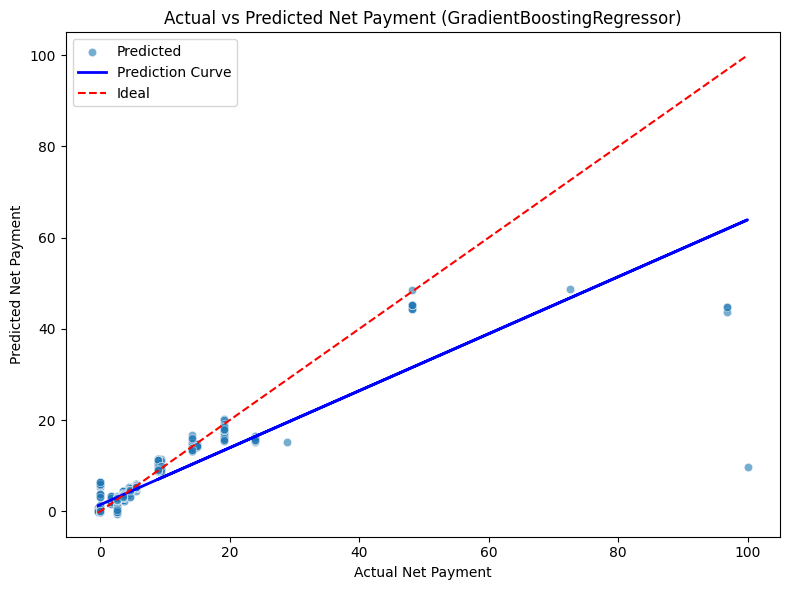

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression
def plot_predictions(y_true, y_pred, model_name="Model"):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, label="Predicted")

    # Fit and plot regression line
    reg = LinearRegression().fit(np.array(y_true).reshape(-1, 1), y_pred)
    y_fit = reg.predict(np.array(y_true).reshape(-1, 1))
    plt.plot(y_true, y_fit, color='blue', linewidth=2, label="Prediction Curve")

    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label="Ideal")
    plt.xlabel("Actual Net Payment")
    plt.ylabel("Predicted Net Payment")
    plt.title(f"Actual vs Predicted Net Payment ({model_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

y_pred = best_model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
plot_predictions(y_test, y_pred, model_name=type(best_model).__name__)

y_pred_extra = best_model.predict(X_extra)
print("MAE:", mean_absolute_error(y_extra, y_pred_extra))
print("R2:", r2_score(y_extra, y_pred_extra))
plot_predictions(y_extra, y_pred_extra, model_name=type(best_model).__name__)